# 03 — Modelagem

## Grupo 50 • Tech Challenge — Fase 2

Neste notebook são treinados e comparados três classificadores: **KNN, Regressão Logística e Random Forest**.

A divisão entre treino, validação e teste é realizada por **perfil cadastral**, utilizando `StratifiedGroupKFold`. Dessa forma, registros que representam o mesmo perfil permanecem no mesmo conjunto, evitando que informações de perfis equivalentes apareçam simultaneamente em treino e teste.

O objetivo é avaliar a capacidade de generalização dos modelos em uma base fortemente desbalanceada, priorizando métricas adequadas à identificação da classe de **maus pagadores (`TARGET = 1`)**.


In [1]:
# Reprodutibilidade
RANDOM_STATE = 42

# A divisão agrupada utiliza uma semente própria para tornar o particionamento
# completamente reproduzível.
SPLIT_RANDOM_STATE = 7

from pathlib import Path
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")


## 1. Localização dos arquivos

O notebook funciona no repositório local e também pode ser adaptado para execução em ambiente de notebook externo.

A base utilizada nesta etapa é a saída do notebook de pré-processamento:
`data/processed/base_modelagem.csv`.


In [2]:
# Localiza a raiz do projeto de forma robusta
candidatos = [
    Path.cwd(),
    Path.cwd().parent,
]

ROOT = None
for candidato in candidatos:
    if (candidato / "data" / "processed" / "base_modelagem.csv").exists():
        ROOT = candidato
        break

if ROOT is None:
    raise FileNotFoundError(
        "Não foi encontrada data/processed/base_modelagem.csv. "
        "Execute primeiro o notebook 02_preprocessamento."
    )

PROC = ROOT / "data" / "processed"
FIG_DIR = ROOT / "docs" / "figuras_modelagem"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Raiz do projeto:", ROOT)
print("Base de modelagem:", PROC / "base_modelagem.csv")


Raiz do projeto: c:\projetos\Grupo_50_Tech-Challenge-Fase-2
Base de modelagem: c:\projetos\Grupo_50_Tech-Challenge-Fase-2\data\processed\base_modelagem.csv


In [3]:
# Carregamento da base preparada no pré-processamento
dados = pd.read_csv(PROC / "base_modelagem.csv")

print("Dimensão da base:", dados.shape)
print("TARGET nulos:", int(dados["TARGET"].isna().sum()))
print("PROFILE_GROUP nulos:", int(dados["PROFILE_GROUP"].isna().sum()))

display(dados.head())


Dimensão da base: (36457, 22)
TARGET nulos: 0
PROFILE_GROUP nulos: 0


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,PROFILE_GROUP,AGE_YEARS,EMPLOYED_YEARS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,NaN,2.0,0,9179,32.87,12.44
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,NaN,2.0,0,9179,32.87,12.44
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,1,0,0,0,Security staff,2.0,0,8456,58.79,3.10
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,0,3178,52.32,8.35
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,0,3178,52.32,8.35


## 2. Preparação das variáveis

`TARGET` representa a variável resposta:

- `0` = bom pagador
- `1` = mau pagador

O agrupamento cadastral utilizado no split é reconstruído com `hash_pandas_object`, seguindo a mesma lógica metodológica da avaliação final. O identificador de grupo **não entra como variável preditora**.

As variáveis `ID`, `DAYS_BIRTH` e `DAYS_EMPLOYED` não são utilizadas diretamente, pois as informações de idade e tempo de emprego já foram derivadas no pré-processamento.

**Importante:** não fazemos imputação, codificação ou escalonamento nesta etapa. Essas transformações serão ajustadas exclusivamente no conjunto de treinamento depois da divisão, evitando vazamento de informação.


In [4]:
# Cópia da base para a etapa de modelagem
dados_modelo = dados.copy()

# TARGET
y = dados_modelo["TARGET"].astype(int)

# Reconstrução do grupo cadastral.
# O mesmo perfil cadastral deve permanecer inteiro em um único conjunto.
colunas_perfil = [
    c for c in dados_modelo.columns
    if c not in ["ID", "TARGET", "PROFILE_GROUP"]
]

groups = pd.util.hash_pandas_object(
    dados_modelo[colunas_perfil].astype(str),
    index=False,
).astype(str)

# Variáveis preditoras
colunas_excluir = [
    "TARGET",
    "PROFILE_GROUP",
    "ID",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
]

X = dados_modelo.drop(
    columns=[c for c in colunas_excluir if c in dados_modelo.columns]
).copy()

print("Quantidade de observações:", len(X))
print("Quantidade de variáveis antes do encoding:", X.shape[1])
print("Quantidade de grupos cadastrais:", groups.nunique())
print("Valores ausentes antes do split:", int(X.isna().sum().sum()))


Quantidade de observações: 36457
Quantidade de variáveis antes do encoding: 17
Quantidade de grupos cadastrais: 9728
Valores ausentes antes do split: 17458


## 3. Divisão treino, validação e teste por grupo

Um `train_test_split` aleatório pode separar registros pertencentes ao mesmo perfil cadastral. Para evitar esse problema, utilizamos `StratifiedGroupKFold`.

O objetivo é obter aproximadamente:

- **70%** para treinamento;
- **15%** para validação;
- **15%** para teste;

mantendo, dentro da restrição de grupos, uma distribuição de `TARGET` próxima da distribuição global.

A escolha dos dois folds de aproximadamente 15% é feita considerando simultaneamente o tamanho do fold e a prevalência da classe positiva.


In [5]:
# Divisão estratificada e agrupada
sgkf = StratifiedGroupKFold(
    n_splits=7,
    shuffle=True,
    random_state=SPLIT_RANDOM_STATE,
)

folds = list(sgkf.split(X, y, groups=groups))

prevalencia_global = y.mean()
avaliacao_folds = []

for fold_id, (_, idx_fold) in enumerate(folds):
    proporcao = len(idx_fold) / len(X)
    prevalencia = y.iloc[idx_fold].mean()
    score = abs(proporcao - 0.15) + abs(prevalencia - prevalencia_global)

    avaliacao_folds.append(
        (fold_id, proporcao, prevalencia, score)
    )

avaliacao_folds_df = pd.DataFrame(
    avaliacao_folds,
    columns=["fold", "proporcao", "prevalencia_mau", "score"],
).sort_values("score")

display(
    avaliacao_folds_df.style.format({
        "proporcao": "{:.2%}",
        "prevalencia_mau": "{:.2%}",
        "score": "{:.5f}",
    })
)

# Melhor fold para teste
fold_teste = int(avaliacao_folds_df.iloc[0]["fold"])

# Melhor fold restante para validação
fold_validacao = int(
    avaliacao_folds_df[
        avaliacao_folds_df["fold"] != fold_teste
    ].sort_values("score").iloc[0]["fold"]
)

idx_teste = folds[fold_teste][1]
idx_validacao = folds[fold_validacao][1]

idx_treino = np.setdiff1d(
    np.arange(len(X)),
    np.concatenate([idx_teste, idx_validacao]),
)

X_train = X.iloc[idx_treino].copy()
y_train = y.iloc[idx_treino].copy()

X_val = X.iloc[idx_validacao].copy()
y_val = y.iloc[idx_validacao].copy()

X_test = X.iloc[idx_teste].copy()
y_test = y.iloc[idx_teste].copy()

print("Fold de teste:", fold_teste)
print("Fold de validação:", fold_validacao)
print()
print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)


,fold,proporcao,prevalencia_mau,score
4,4,14.72%,1.70%,0.00284
0,0,14.67%,1.83%,0.00477
3,3,14.46%,1.65%,0.00583
1,1,14.38%,1.74%,0.00662
6,6,14.11%,1.83%,0.01025
5,5,14.17%,1.47%,0.01046
2,2,13.49%,1.61%,0.01596


Fold de teste: 4
Fold de validação: 0

Treino: (25743, 17)
Validação: (5347, 17)
Teste: (5367, 17)


In [6]:
# Distribuição do TARGET nos três conjuntos
distribuicao_split = pd.DataFrame({
    "Conjunto": ["Treino", "Validação", "Teste"],
    "Total": [len(y_train), len(y_val), len(y_test)],
    "Maus_pagadores": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "Percentual_mau": [y_train.mean(), y_val.mean(), y_test.mean()],
})

display(
    distribuicao_split.style.format({
        "Percentual_mau": "{:.2%}"
    })
)


,Conjunto,Total,Maus_pagadores,Percentual_mau
0,Treino,25743,427,1.66%
1,Validação,5347,98,1.83%
2,Teste,5367,91,1.70%


## 4. Verificação de sobreposição de perfis

A validação abaixo confirma que nenhum `PROFILE_GROUP` aparece simultaneamente em dois conjuntos.

Essa checagem é importante porque o principal risco de um split aleatório, neste projeto, é permitir que registros equivalentes sejam utilizados tanto para aprendizado quanto para avaliação.


In [7]:
perfis_treino = set(groups.iloc[idx_treino])
perfis_validacao = set(groups.iloc[idx_validacao])
perfis_teste = set(groups.iloc[idx_teste])

sobreposicao = pd.DataFrame({
    "Comparação": [
        "Treino × Validação",
        "Treino × Teste",
        "Validação × Teste",
    ],
    "Perfis em comum": [
        len(perfis_treino & perfis_validacao),
        len(perfis_treino & perfis_teste),
        len(perfis_validacao & perfis_teste),
    ],
})

display(sobreposicao)

assert len(perfis_treino & perfis_validacao) == 0
assert len(perfis_treino & perfis_teste) == 0
assert len(perfis_validacao & perfis_teste) == 0

print("OK: nenhum perfil cadastral aparece em mais de um conjunto.")


,Comparação,Perfis em comum
0,Treino × Validação,0
1,Treino × Teste,0
2,Validação × Teste,0


OK: nenhum perfil cadastral aparece em mais de um conjunto.


## 5. Pré-processamento sem vazamento

O tratamento abaixo é ajustado **somente no conjunto de treinamento**:

- numéricas: mediana calculada no treino;
- categóricas: moda calculada no treino;
- categóricas: one-hot encoding aprendido no treino;
- KNN e Regressão Logística: MinMaxScaler ajustado no treino;
- Random Forest: utiliza a matriz imputada/codificada, sem escalonamento.

Assim, validação e teste não influenciam nenhuma estatística de pré-processamento.


In [8]:
# Identificação das colunas pelo conjunto de treinamento
colunas_categoricas = X_train.select_dtypes(include=["object"]).columns.tolist()
colunas_numericas = X_train.select_dtypes(exclude=["object"]).columns.tolist()

preprocessador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            SimpleImputer(strategy="median"),
            colunas_numericas,
        ),
        (
            "categoricas",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "onehot",
                    OneHotEncoder(
                        drop="first",
                        handle_unknown="ignore",
                        sparse_output=False,
                    ),
                ),
            ]),
            colunas_categoricas,
        ),
    ],
    remainder="drop",
)

# Ajuste SOMENTE no treino
X_train_proc = preprocessador.fit_transform(X_train)

# Aplicação, sem novo ajuste, nos demais conjuntos
X_val_proc = preprocessador.transform(X_val)
X_test_proc = preprocessador.transform(X_test)

nomes_features = preprocessador.get_feature_names_out()

# DataFrames preservam os nomes das variáveis para a análise de importância
X_train = pd.DataFrame(
    X_train_proc,
    index=X_train.index,
    columns=nomes_features,
)
X_val = pd.DataFrame(
    X_val_proc,
    index=X_val.index,
    columns=nomes_features,
)
X_test = pd.DataFrame(
    X_test_proc,
    index=X_test.index,
    columns=nomes_features,
)

# Escalonamento somente para KNN e Regressão Logística
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Quantidade de variáveis após o encoding:", X_train.shape[1])
print("Valores ausentes após o pré-processamento:", int(X_train.isna().sum().sum()))
print("Escalonamento concluído.")
print("Treino:", X_train_scaled.shape)
print("Validação:", X_val_scaled.shape)
print("Teste:", X_test_scaled.shape)


Quantidade de variáveis após o encoding: 46
Valores ausentes após o pré-processamento: 0
Escalonamento concluído.
Treino: (25743, 46)
Validação: (5347, 46)
Teste: (5367, 46)


## 6. KNN — seleção do hiperparâmetro

São avaliados valores de `K` de 1 a 10.

A seleção utiliza o **F1-score da classe 1 (mau pagador)** na validação. Essa escolha é adequada ao problema porque a classe positiva é minoritária e tanto falsos positivos quanto falsos negativos precisam ser considerados.

O conjunto de teste não participa dessa escolha.


In [9]:
f1_validacao = []

for k in range(1, 11):
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train_scaled, y_train)

    pred_val = modelo.predict(X_val_scaled)

    f1_validacao.append(
        f1_score(y_val, pred_val, zero_division=0)
    )

knn_resultados = pd.DataFrame({
    "K": range(1, 11),
    "F1_validacao": f1_validacao,
})

melhor_k = int(
    knn_resultados.loc[
        knn_resultados["F1_validacao"].idxmax(),
        "K"
    ]
)

display(
    knn_resultados.style.format({
        "F1_validacao": "{:.4f}"
    })
)

print("Melhor K:", melhor_k)


,K,F1_validacao
0,1,0.0379
1,2,0.0000
2,3,0.0146
3,4,0.0000
4,5,0.0167
5,6,0.0000
6,7,0.0000
7,8,0.0000
8,9,0.0000
9,10,0.0000


Melhor K: 1


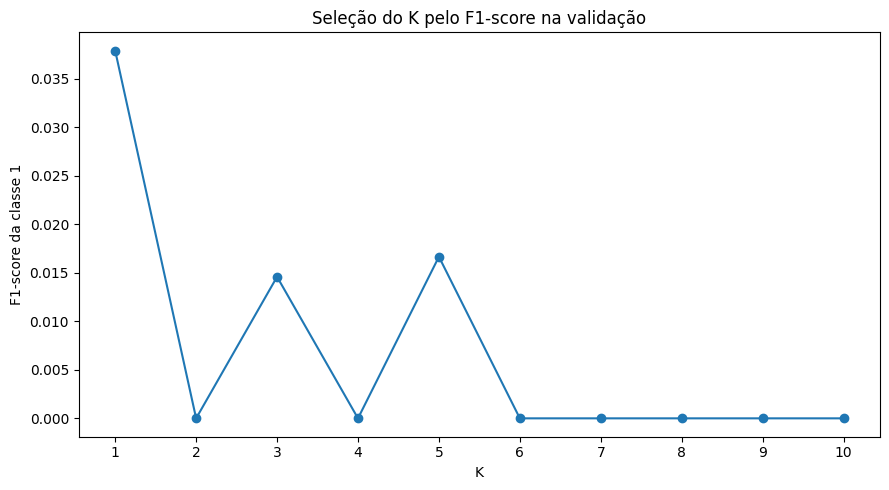

In [10]:
plt.figure(figsize=(9, 5))
plt.plot(
    knn_resultados["K"],
    knn_resultados["F1_validacao"],
    marker="o",
)
plt.xlabel("K")
plt.ylabel("F1-score da classe 1")
plt.title("Seleção do K pelo F1-score na validação")
plt.xticks(range(1, 11))
plt.tight_layout()

plt.savefig(
    FIG_DIR / "01_selecao_k_knn.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


## 7. Treinamento dos três modelos

Serão comparados:

1. **KNN**, com o melhor `K` identificado na validação;
2. **Regressão Logística**, utilizando `class_weight="balanced"`;
3. **Random Forest**, também com ponderação das classes.

A mesma divisão de treino, validação e teste é utilizada pelos três modelos.


In [11]:
# KNN
modelo_knn = KNeighborsClassifier(
    n_neighbors=melhor_k
)
modelo_knn.fit(X_train_scaled, y_train)

# Regressão Logística
modelo_logistico = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
modelo_logistico.fit(X_train_scaled, y_train)

# Random Forest
modelo_floresta = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
modelo_floresta.fit(X_train, y_train)

print("Treinamento dos três modelos concluído.")


Treinamento dos três modelos concluído.


## 8. Avaliação no conjunto de teste

A avaliação final utiliza:

- **Accuracy**;
- **Precision** da classe 1;
- **Recall** da classe 1;
- **F1-score** da classe 1;
- **AUC-ROC**.

A acurácia é apresentada como informação complementar, pois a base possui forte desbalanceamento. Para a seleção do modelo, o principal critério é o **F1-score da classe de maus pagadores**.


In [12]:
# Predições
pred_knn = modelo_knn.predict(X_test_scaled)
pred_logistico = modelo_logistico.predict(X_test_scaled)
pred_floresta = modelo_floresta.predict(X_test)

# Probabilidades para AUC
prob_knn = modelo_knn.predict_proba(X_test_scaled)[:, 1]
prob_logistico = modelo_logistico.predict_proba(X_test_scaled)[:, 1]
prob_floresta = modelo_floresta.predict_proba(X_test)[:, 1]

def avaliar_modelo(nome, y_real, y_pred, probabilidade):
    return {
        "Modelo": nome,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred, zero_division=0),
        "Recall": recall_score(y_real, y_pred, zero_division=0),
        "F1": f1_score(y_real, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_real, probabilidade),
    }

resultados_teste = pd.DataFrame([
    avaliar_modelo("KNN", y_test, pred_knn, prob_knn),
    avaliar_modelo("Regressão Logística", y_test, pred_logistico, prob_logistico),
    avaliar_modelo("Random Forest", y_test, pred_floresta, prob_floresta),
])

resultados_teste = resultados_teste.sort_values(
    "F1",
    ascending=False,
).reset_index(drop=True)

display(
    resultados_teste.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC": "{:.4f}",
    })
)

modelo_final_nome = resultados_teste.iloc[0]["Modelo"]

print("Modelo selecionado pelo maior F1 da classe 1:", modelo_final_nome)


,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Random Forest,0.9493,0.0452,0.0989,0.0621,0.6109
1,Regressão Logística,0.6231,0.0160,0.3516,0.0307,0.5065
2,KNN,0.9650,0.0198,0.0220,0.0208,0.5016


Modelo selecionado pelo maior F1 da classe 1: Random Forest


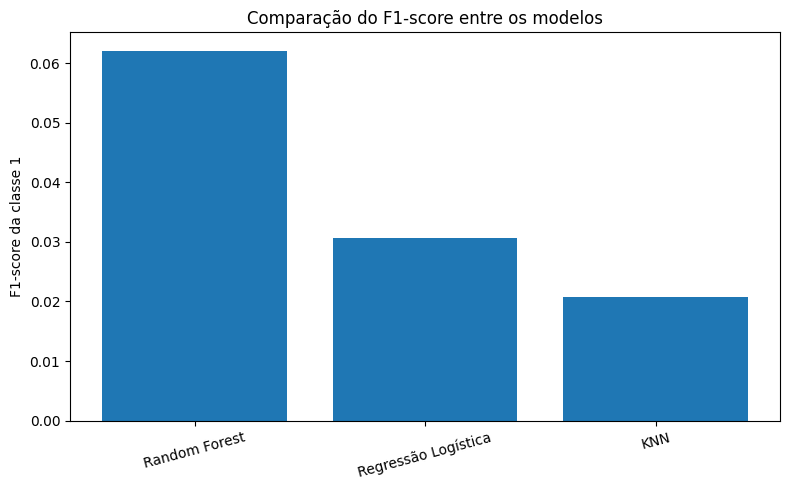

In [13]:
# Comparação visual do F1 dos modelos
plt.figure(figsize=(8, 5))
plt.bar(
    resultados_teste["Modelo"],
    resultados_teste["F1"],
)
plt.ylabel("F1-score da classe 1")
plt.title("Comparação do F1-score entre os modelos")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "02_comparacao_f1_modelos.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


## 9. Matrizes de confusão

As matrizes de confusão ajudam a interpretar os erros de classificação, especialmente os casos em que um mau pagador é classificado como bom.


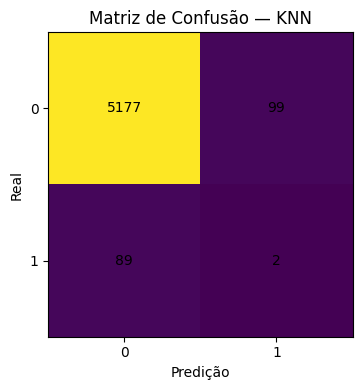

In [14]:
def mostrar_matriz(y_real, y_pred, titulo, caminho):
    matriz = confusion_matrix(y_real, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(matriz)

    ax.set_title(titulo)
    ax.set_xlabel("Predição")
    ax.set_ylabel("Real")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, matriz[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.savefig(caminho, dpi=150, bbox_inches="tight")
    plt.show()

mostrar_matriz(
    y_test,
    pred_knn,
    "Matriz de Confusão — KNN",
    FIG_DIR / "04_matriz_confusao_knn.png",
)


## 10. Importância das variáveis — Random Forest

A importância das variáveis indica quais atributos contribuíram mais para as decisões do Random Forest.

Essa medida representa contribuição para o modelo e **não deve ser interpretada como causalidade**.


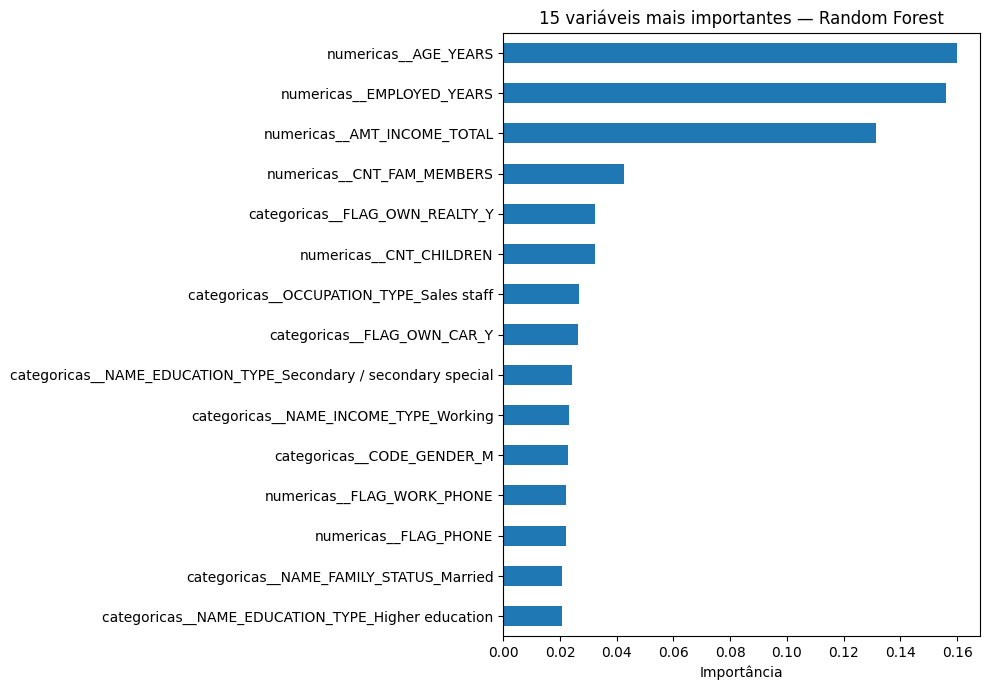

,Importância
numericas__AGE_YEARS,0.1601
numericas__EMPLOYED_YEARS,0.1562
numericas__AMT_INCOME_TOTAL,0.1316
numericas__CNT_FAM_MEMBERS,0.0425
categoricas__FLAG_OWN_REALTY_Y,0.0324
numericas__CNT_CHILDREN,0.0322
categoricas__OCCUPATION_TYPE_Sales staff,0.0267
categoricas__FLAG_OWN_CAR_Y,0.0262
categoricas__NAME_EDUCATION_TYPE_Secondary / secondary special,0.0241
categoricas__NAME_INCOME_TYPE_Working,0.0231


In [15]:
importancias = pd.Series(
    modelo_floresta.feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False)

importancias_top = importancias.head(15)

plt.figure(figsize=(10, 7))
importancias_top.sort_values().plot(kind="barh")
plt.xlabel("Importância")
plt.title("15 variáveis mais importantes — Random Forest")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "03_importancia_random_forest.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

display(
    importancias_top.to_frame("Importância").style.format({
        "Importância": "{:.4f}"
    })
)


## 11. Diagnóstico de ajuste

Comparamos a acurácia de treinamento e teste como diagnóstico complementar de ajuste dos modelos.


In [16]:
diagnostico_ajuste = pd.DataFrame({
    "Modelo": [
        "KNN",
        "Regressão Logística",
        "Random Forest",
    ],
    "Accuracy_treino": [
        modelo_knn.score(X_train_scaled, y_train),
        modelo_logistico.score(X_train_scaled, y_train),
        modelo_floresta.score(X_train, y_train),
    ],
    "Accuracy_teste": [
        modelo_knn.score(X_test_scaled, y_test),
        modelo_logistico.score(X_test_scaled, y_test),
        modelo_floresta.score(X_test, y_test),
    ],
})

display(
    diagnostico_ajuste.style.format({
        "Accuracy_treino": "{:.4f}",
        "Accuracy_teste": "{:.4f}",
    })
)


,Modelo,Accuracy_treino,Accuracy_teste
0,KNN,0.9875,0.9650
1,Regressão Logística,0.6195,0.6231
2,Random Forest,0.9557,0.9493


## 12. Consolidação dos resultados

O modelo final é selecionado pelo maior **F1-score da classe de maus pagadores**.

Recall e AUC são mantidos como métricas complementares para a interpretação de risco. Em particular, uma AUC próxima de 0,5 indica capacidade discriminativa limitada.


In [17]:
# Consolidação final
resultado_final = resultados_teste.copy()

melhor_f1 = resultado_final.iloc[0]
melhor_recall = resultado_final.loc[resultado_final["Recall"].idxmax()]
melhor_auc = resultado_final.loc[resultado_final["AUC"].idxmax()]

print("Modelo selecionado:", melhor_f1["Modelo"])
print(f"F1 do modelo selecionado: {melhor_f1['F1']:.4f}")
print(
    f"Melhor Recall: {melhor_recall['Modelo']} "
    f"({melhor_recall['Recall']:.4f})"
)
print(
    f"Melhor AUC: {melhor_auc['Modelo']} "
    f"({melhor_auc['AUC']:.4f})"
)

display(
    resultado_final.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC": "{:.4f}",
    })
)


Modelo selecionado: Random Forest
F1 do modelo selecionado: 0.0621
Melhor Recall: Regressão Logística (0.3516)
Melhor AUC: Random Forest (0.6109)


,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Random Forest,0.9493,0.0452,0.0989,0.0621,0.6109
1,Regressão Logística,0.6231,0.0160,0.3516,0.0307,0.5065
2,KNN,0.9650,0.0198,0.0220,0.0208,0.5016


## 13. Salvamento dos artefatos

Os modelos treinados e as tabelas de resultados podem ser utilizados pelo notebook 04 e ficam em `data/processed/`, diretório que não deve ser versionado pelo Git.

As figuras de modelagem são salvas em `docs/figuras_modelagem/`.

Nenhum arquivo `.pkl` ou `.joblib` deve ser enviado ao repositório público.


In [18]:
# Salva modelos e resultados localmente para uso nas etapas seguintes.
# Esses artefatos não devem ser versionados no Git.
modelos_treinados = {
    "KNN": modelo_knn,
    "Regressão Logística": modelo_logistico,
    "Random Forest": modelo_floresta,
}

joblib.dump(
    modelos_treinados,
    PROC / "modelos_treinados.joblib",
)

resultado_final.to_csv(
    PROC / "resultados_teste_modelagem.csv",
    index=False,
)

knn_resultados.to_csv(
    PROC / "resultados_knn_k.csv",
    index=False,
)

importancias_top.to_frame("Importância").to_csv(
    PROC / "importancia_random_forest.csv"
)

diagnostico_ajuste.to_csv(
    PROC / "diagnostico_ajuste.csv",
    index=False,
)

print("Artefatos salvos em:", PROC)
print("Figuras salvas em:", FIG_DIR)


Artefatos salvos em: c:\projetos\Grupo_50_Tech-Challenge-Fase-2\data\processed
Figuras salvas em: c:\projetos\Grupo_50_Tech-Challenge-Fase-2\docs\figuras_modelagem


## Conclusão

A modelagem compara três classificadores sob uma divisão estratificada e agrupada por perfil cadastral.

A seleção do modelo considera o F1 da classe de maus pagadores, enquanto Recall, Precision e AUC complementam a análise. A divisão por grupos reduz o risco de avaliar o modelo sobre perfis equivalentes aos utilizados no treinamento.

Os resultados desta etapa devem ser utilizados em conjunto com a análise exploratória e o pré-processamento para a avaliação final do projeto.
